# MoXpert — Results Analysis (รันบน Mac / local)

วิเคราะห์ผลจาก `Results_Qwen2VL.csv` ที่ได้จากการรัน evaluation (บน Colab/RunPod) โดยไม่ต้องโหลดโมเดลหรือ dataset — ใช้แค่ไฟล์ CSV + annotation

**เนื้อหา:** accuracy ต่อ question type → เทียบกับ paper เดิม → confusion matrix

> ก่อนรัน: ดาวน์โหลด `Results_Qwen2VL.csv` จาก Colab/Drive มาไว้ที่ `Experiments/Results_Qwen2VL.csv` ในโปรเจกต์ (หรือแก้ `CSV_PATH` ในเซลล์ Config ให้ชี้ไปที่ไฟล์)

## 0. ติดตั้ง dependencies (ครั้งเดียว)

ต้องมี pandas, matplotlib, scikit-learn — ถ้ามีอยู่แล้วข้ามได้

In [1]:
%pip install -q pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Config — ตั้ง path

หา repo root อัตโนมัติจากตำแหน่ง notebook (ไต่ขึ้นไปจนเจอ `Annotation/DS-MVTec.json`) ถ้า CSV อยู่ที่อื่น (เช่น `~/Downloads`) ให้แก้ `CSV_PATH` เอง

In [2]:
from pathlib import Path

p = Path.cwd()
while p != p.parent and not (p / 'Annotation' / 'DS-MVTec.json').exists():
    p = p.parent
REPO = p

ANN_PATH = REPO / 'Annotation' / 'DS-MVTec.json'
CSV_PATH = REPO / 'Experiments' / 'Results_Qwen2VL.csv'   # 👉 แก้ path นี้ได้ถ้าไฟล์อยู่ที่อื่น

assert ANN_PATH.exists(), f'ไม่พบ annotation: {ANN_PATH}'
assert CSV_PATH.exists(), f'ไม่พบ CSV: {CSV_PATH} — ดาวน์โหลดมาวางก่อน'
print('REPO:', REPO)
print('CSV :', CSV_PATH)

REPO: /Users/jaypoom/Desktop/AI Project/MoXpert
CSV : /Users/jaypoom/Desktop/AI Project/MoXpert/Experiments/Results_Qwen2VL.csv


## 1. Accuracy ต่อ Question Type

อ่าน CSV แล้ว join กับ annotation ผ่าน key `(Image Path, Question)` เพื่อหา question type (CSV ไม่มีคอลัมน์ type) จากนั้นดึงตัวอักษรตัวเลือก A-D จากทั้ง prediction และเฉลย

In [3]:
import json, re
import pandas as pd

with open(ANN_PATH) as f:
    ann = json.load(f)
qtype = {}
for img, v in ann.items():
    for c in v['conversation']:
        qtype[(img, c['Question'])] = c['type']

def extract_letter(s):
    """ดึงตัวอักษรตัวเลือก A-D จากคำตอบ โดยไม่จับตัวอักษรที่อยู่กลางคำ"""
    if s is None:
        return None
    t = str(s).strip()
    if t == '' or t.upper() == 'N/A':
        return None
    t = t.upper()
    m = re.match(r'^([A-D])\b', t)      # ขึ้นต้นด้วยตัวเลือกเลย เช่น 'A', 'A.', 'A: Yes'
    if m:
        return m.group(1)
    m = re.search(r'\b([A-D])\b', t)   # ตัวเลือกยืนเดี่ยวกลางประโยค เช่น 'The answer is C'
    return m.group(1) if m else None

df = pd.read_csv(CSV_PATH)
df['Type'] = df.apply(lambda r: qtype.get((r['Image Path'], r['Question']), 'Unknown'), axis=1)
df['Pred'] = df['Predicted Answer'].apply(extract_letter)
df['True'] = df['Correct Answer'].apply(extract_letter)
df['Correct'] = df['Pred'] == df['True']

print(f'Total rows: {len(df)}')
print(f'Unparseable predictions (นับเป็นผิด): {df["Pred"].isna().sum()}')
print(f'Rows with Unknown type (join ไม่ติด): {(df.Type == "Unknown").sum()}')

Total rows: 6507
Unparseable predictions (นับเป็นผิด): 0
Rows with Unknown type (join ไม่ติด): 0


In [4]:
ORDER = ['Anomaly Detection', 'Defect Classification', 'Defect Localization',
         'Defect Description', 'Defect Analysis']

per_type = df.groupby('Type')['Correct'].agg(['mean', 'count'])
per_type = per_type.reindex([t for t in ORDER if t in per_type.index])
per_type['accuracy_%'] = (per_type['mean'] * 100).round(2)

micro = df['Correct'].mean() * 100                 # เฉลี่ยทุกคำถาม
macro = per_type['mean'].mean() * 100              # เฉลี่ยของ per-type

print(per_type[['accuracy_%', 'count']])
print()
print(f'Micro-average (ทุกคำถาม):     {micro:.2f}%')
print(f'Macro-average (เฉลี่ย 5 type): {macro:.2f}%')

                       accuracy_%  count
Type                                    
Anomaly Detection           89.83   1691
Defect Classification       72.78   1205
Defect Localization         76.11   1193
Defect Description          85.49   1213
Defect Analysis             92.95   1205

Micro-average (ทุกคำถาม):     83.93%
Macro-average (เฉลี่ย 5 type): 83.43%


## 2. เทียบกับ Paper เดิม

กรอกค่า accuracy (%) ที่ paper รายงานลงใน `PAPER_ACCURACY` (`None` = ยังไม่กรอก จะแสดง `—`)

> อ้างอิง: Chen & Imani, *A multi-expert framework for enhancing multimodal large language models in industrial anomaly detection*, Pattern Recognition 2025

In [5]:
# 👉 แก้ตัวเลขตรงนี้ให้ตรงกับที่ paper รายงาน (หน่วย: %)
PAPER_ACCURACY = {
    'Anomaly Detection':     89.65,
    'Defect Classification': 72.86,
    'Defect Localization':   76.11,
    'Defect Description':    85.57,
    'Defect Analysis':       93.20,
    'Average':               83.48,
}

rows = []
for t in ORDER:
    if t not in per_type.index:
        continue
    ours = per_type.loc[t, 'accuracy_%']
    paper = PAPER_ACCURACY.get(t)
    diff = round(ours - paper, 2) if paper is not None else None
    rows.append({'Question Type': t, 'Ours (%)': ours,
                 'Paper (%)': paper if paper is not None else '—',
                 'Diff': diff if diff is not None else '—'})

paper_avg = PAPER_ACCURACY.get('Average')
rows.append({'Question Type': 'Average (macro)', 'Ours (%)': round(macro, 2),
             'Paper (%)': paper_avg if paper_avg is not None else '—',
             'Diff': round(macro - paper_avg, 2) if paper_avg is not None else '—'})

cmp_df = pd.DataFrame(rows)
cmp_df

,Question Type,Ours (%),Paper (%),Diff
0,Anomaly Detection,89.83,89.65,0.18
1,Defect Classification,72.78,72.86,-0.08
2,Defect Localization,76.11,76.11,0.00
3,Defect Description,85.49,85.57,-0.08
4,Defect Analysis,92.95,93.20,-0.25
5,Average (macro),83.43,83.48,-0.05


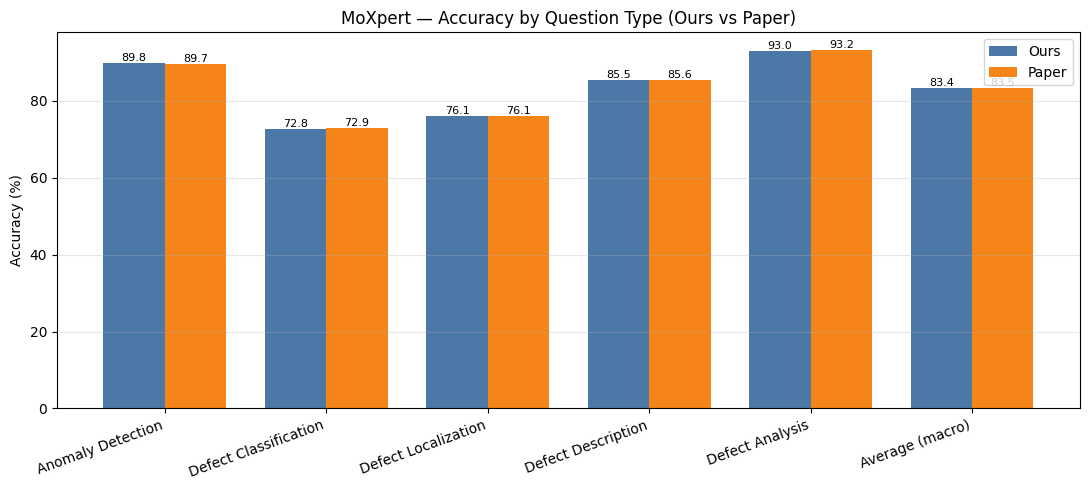

In [9]:
import matplotlib.pyplot as plt
import numpy as np

types = [r['Question Type'] for r in rows]
ours_vals = [r['Ours (%)'] for r in rows]

def paper_of(t):
    v = PAPER_ACCURACY.get('Average') if 'Average' in t else PAPER_ACCURACY.get(t)
    return v if isinstance(v, (int, float)) else np.nan
paper_vals = [paper_of(t) for t in types]

x = np.arange(len(types))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, ours_vals, w, label='Ours', color='#4C78A8')
ax.bar(x + w/2, paper_vals, w, label='Paper', color='#F58518')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MoXpert — Accuracy by Question Type (Ours vs Paper)')
ax.set_xticks(x)
ax.set_xticklabels(types, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(ours_vals):
    ax.text(x[i] - w/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
for i, v in enumerate(paper_vals):
    if not np.isnan(v):
        ax.text(x[i] + w/2, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Confusion Matrix ต่อ Question Type

แถว = เฉลยจริง, คอลัมน์ = คำตอบโมเดล — Anomaly Detection มี 2 ตัวเลือก (A/B) ที่เหลือ 4 ตัวเลือก (A-D) ค่า `?` = prediction ที่ parse ไม่ได้

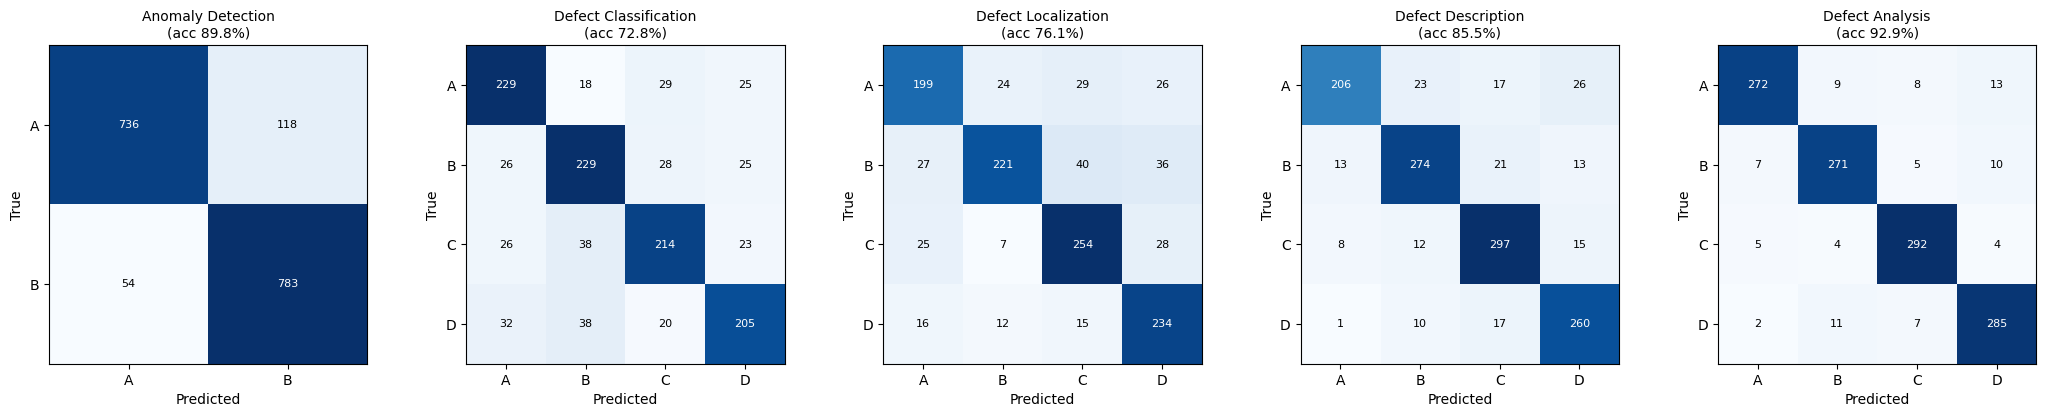

In [10]:
from sklearn.metrics import confusion_matrix

present = [t for t in ORDER if t in df['Type'].unique()]
n = len(present)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
if n == 1:
    axes = [axes]

for ax, t in zip(axes, present):
    sub = df[df['Type'] == t]
    y_true = sub['True'].fillna('?')
    y_pred = sub['Pred'].fillna('?')
    all_labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(all_labels)))
    ax.set_yticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels)
    ax.set_yticklabels(all_labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{t}\n(acc {sub["Correct"].mean() * 100:.1f}%)', fontsize=10)
    for i in range(len(all_labels)):
        for j in range(len(all_labels)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

## 4. บันทึกผลวิเคราะห์ (optional)

In [ ]:
out_dir = REPO / 'Experiments'
per_type.to_csv(out_dir / 'accuracy_by_type.csv')
cmp_df.to_csv(out_dir / 'accuracy_vs_paper.csv', index=False)
print('Saved to', out_dir)